## Case Study: CNN Image Classification with Transfer Learning 


In [11]:


import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(tf.__version__)


2.19.0


# Part 1: Data Exploration & Preprocessing

### Tasks
1. Load CIFAR-10 (tfds or `keras.datasets.cifar10`) and preview shapes.  
2. Visualize a small grid of samples by class; show class distribution.  
3. Implement augmentation strategies (e.g., flips/rotations; optional cutout/mixup).  
4. Analyze pixel intensity distributions and choose normalization strategy.  
5. Create train/val split with balanced classes and a tf.data pipeline.


In [3]:
# ---- CIFAR-10 loading (starter only) ----
# Option A: keras.datasets
from tensorflow.keras.datasets import cifar10
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()
y_train_full = y_train_full.squeeze(); y_test = y_test.squeeze()
print(X_train_full.shape, X_test.shape)

# TODO: Create a validation split from train (e.g., 10%)
# from sklearn.model_selection import train_test_split
# X_train, X_val, y_train, y_val = train_test_split(..., stratify=y_train_full, random_state=SEED)

# TODO: Normalize images (e.g., /255.0) and cast dtypes
# ---- CIFAR-10 loading (starter only) ----
from tensorflow.keras.datasets import cifar10
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()
y_train_full = y_train_full.squeeze(); y_test = y_test.squeeze()
print(X_train_full.shape, X_test.shape)

# --- Create validation split ---
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.1,
    stratify=y_train_full,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

# --- Normalize images ---
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0


(50000, 32, 32, 3) (10000, 32, 32, 3)
(50000, 32, 32, 3) (10000, 32, 32, 3)
Train shape: (45000, 32, 32, 3)
Validation shape: (5000, 32, 32, 3)


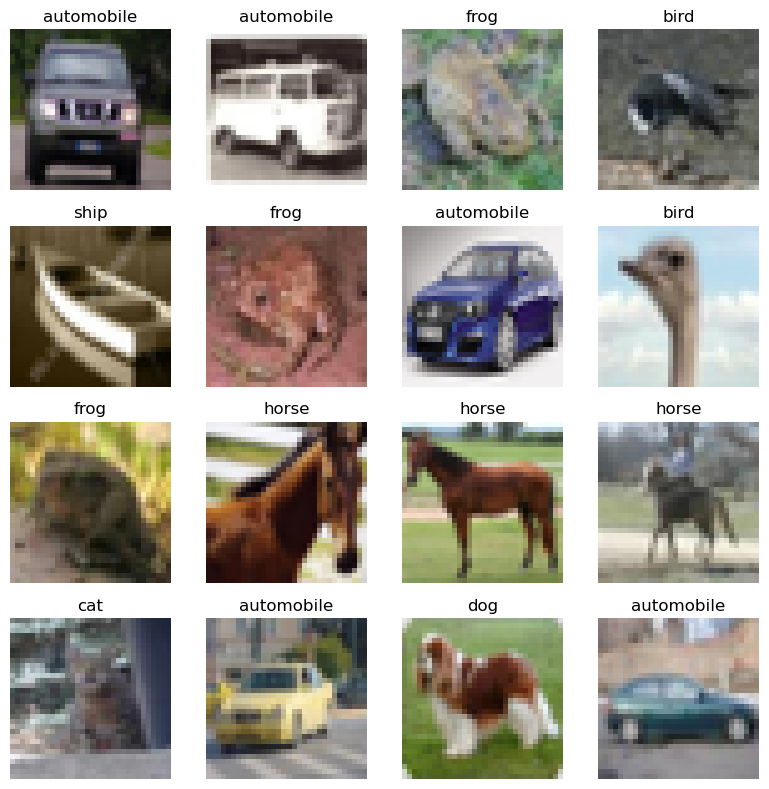

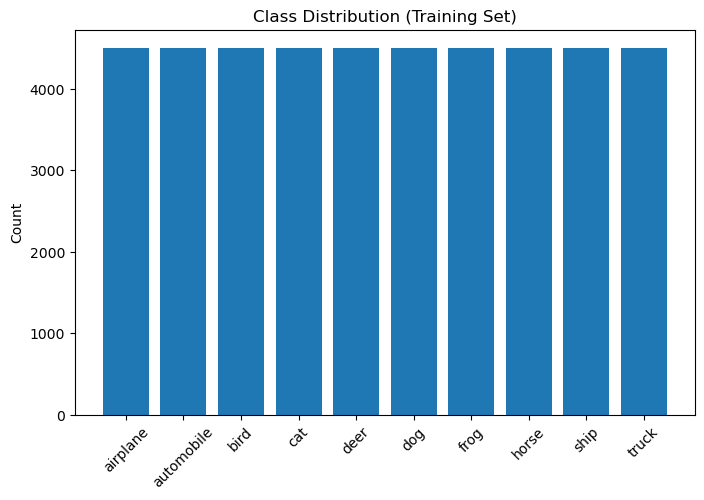

In [4]:
# ---- Visualization ----
import matplotlib.pyplot as plt
import numpy as np

# Class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# --- Plot 4x4 grid ---
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


# --- Plot class distribution ---
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution (Training Set)")
plt.ylabel("Count")
plt.show()

In [5]:
# ---- Augmentation ----
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")


# ---- tf.data pipeline ----
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Training dataset (with augmentation)
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=10000, seed=SEED)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                        num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)


# Validation dataset (NO augmentation)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


# Test dataset (NO augmentation)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


# Part 2: Custom CNN Architecture Design

### Tasks
1. Build a **baseline** CNN (conv blocks + pooling).  
2. Add techniques: BatchNorm, Dropout, optional residual connections.  
3. Explore kernel sizes, pooling, and activations; compare small variants.  
4. Optimize the architecture for CIFAR-10; keep parameter count reasonable.


In [6]:
# ---- Custom CNN model ----
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3, 3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="custom_cnn")
    return model


custom_cnn = build_custom_cnn()

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

history_custom = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

custom_test_loss, custom_test_acc = custom_cnn.evaluate(test_ds)

print("Custom CNN Test Loss:", custom_test_loss)
print("Custom CNN Test Accuracy:", custom_test_acc)

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.2823 - loss: 1.9569 - val_accuracy: 0.4586 - val_loss: 1.4520
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.4164 - loss: 1.5574 - val_accuracy: 0.5438 - val_loss: 1.2439
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 19ms/step - accuracy: 0.4619 - loss: 1.4436 - val_accuracy: 0.5856 - val_loss: 1.1317
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.4932 - loss: 1.3601 - val_accuracy: 0.6078 - val_loss: 1.1106
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.5238 - loss: 1.2912 - val_accuracy: 0.5166 - val_loss: 1.3155
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5210 - loss: 1.3122
Custom CNN Test Loss: 1.3288226127624512
Custom CNN Test Accuracy: 0.5134000182151794


# Part 3: Transfer Learning Implementation

### Tasks
1. Use **pre-trained** models (VGG16, ResNet50, EfficientNetB0) with `include_top=False`.  
2. Compare **feature extraction** vs **fine-tuning**.  
3. Experiment with freezing/unfreezing strategies and layer-wise learning rates.  
4. Evaluate compute vs accuracy trade-offs.


In [7]:
# ---- Transfer learning model ----
def build_tl_model(base_name="EfficientNetB0", input_shape=(224,224,3), num_classes=10, train_base=False):
    inputs = keras.Input(shape=(32,32,3))
    x = data_augmentation(inputs)
    x = layers.Resizing(input_shape[0], input_shape[1])(x)

    bases = {
        "VGG16": keras.applications.VGG16,
        "ResNet50": keras.applications.ResNet50,
        "EfficientNetB0": keras.applications.EfficientNetB0,
    }

    Base = bases[base_name]
    base_model = Base(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = train_base

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=f"tl_{base_name.lower()}")


# Phase 1: feature extraction
tl_model = build_tl_model(base_name="EfficientNetB0", train_base=False)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

history_tl_feature = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

# Phase 2: fine-tuning
tl_model.layers[2].trainable = True

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_tl_finetune = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2
)

tl_test_loss, tl_test_acc = tl_model.evaluate(test_ds)

print("Transfer Learning Test Loss:", tl_test_loss)
print("Transfer Learning Test Accuracy:", tl_test_acc)

Model: "tl_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 387s 274ms/step - accuracy: 0.1020 - loss: 2.3390 - val_accuracy: 0.1000 - val_loss: 2.3163
Epoch 2/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10005s 7s/step - accuracy: 0.0978 - loss: 2.3359 - val_accuracy: 0.1000 - val_loss: 2.3172
Epoch 3/3
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 387s 275ms/step - accuracy: 0.0983 - loss: 2.3339 - val_accuracy: 0.1000 - val_loss: 2.3359
Epoch 1/2
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 392s 277ms/step - accuracy: 0.0991 - loss: 2.3148 - val_accuracy: 0.1000 - val_loss: 2.3040
Epoch 2/2
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 388s 276ms/step - accuracy: 0.1017 - loss: 2.3137 - val_accuracy: 0.1000 - val_loss: 2.3041
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 246ms/step - accuracy: 0.0988 - loss: 2.3038
Transfer Learning Test Loss: 2.304140329360962
Transfer Learning Test Accuracy: 0.10000000149011612


# Part 4: Advanced CNN Techniques

### Tasks
1. Implement a simple **attention** mechanism (channel or spatial).  
2. Try additional regularization (e.g., DropBlock) or stronger augmentation policies.  
3. Experiment with modern optimizers / LR schedules.  
4. Compare loss functions and optional label smoothing.


In [10]:
# ---- Attention block: Squeeze-and-Excitation ----
def se_block(x, reduction=16):
    channels = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, channels))(se)

    return layers.Multiply()([x, se])


def build_attention_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = se_block(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="attention_cnn")


attention_cnn = build_attention_cnn()

lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=1000
)

attention_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

attention_cnn.summary()

history_attention = attention_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

attention_test_loss, attention_test_acc = attention_cnn.evaluate(test_ds)

print("Attention CNN Test Loss:", attention_test_loss)
print("Attention CNN Test Accuracy:", attention_test_acc)

# ---- Final Accuracy Results ----
training_accuracy = history_attention.history['accuracy'][-1] * 100
validation_accuracy = history_attention.history['val_accuracy'][-1] * 100
test_accuracy = attention_test_acc * 100

print(f"Training Accuracy: {training_accuracy:.2f}%")
print(f"Validation Accuracy: {validation_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Model: "attention_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_6[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_9[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 2)         │         66 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 32)        │         96 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 32, 32,    │          0 │ re_lu_9[0][0],    │
│ (Multiply)          │ 32)               │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ multiply_6[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_10[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │        320 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_7 (Reshape) │ (None, 1, 1, 64)  │          0 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 16, 16,    │          0 │ re_lu_10[0][0], 

 Total params: 98,360 (384.22 KB)

 Trainable params: 97,912 (382.47 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.3407 - loss: 1.7792 - val_accuracy: 0.3838 - val_loss: 1.7844
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.4625 - loss: 1.4803 - val_accuracy: 0.5064 - val_loss: 1.3485
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.4957 - loss: 1.3863 - val_accuracy: 0.4248 - val_loss: 1.6234
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5251 - loss: 1.3169 - val_accuracy: 0.5148 - val_loss: 1.3745
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.5591 - loss: 1.2275 - val_accuracy: 0.3900 - val_loss: 1.8070
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.5438 - loss: 1.2742 - val_accuracy: 0.4524 - val_loss: 1.6653
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5639 - loss: 1.2144 - val_accuracy: 0.5354 - val_loss: 1.2590
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.5811 -

# Part 5: Written Analysis & Reflection 

### Write-up Prompts (300–500 words)

1. Summarize your CNN experiments and compare **custom vs transfer** performance.  
2. Discuss interpretability findings (e.g., Grad-CAM, filter visualizations).  
3. Identify one ethical concern (data bias, privacy, misuse) and its impact.  
4. Explain how augmentation/architecture choices affect fairness across classes.  
5. Provide recommendations for responsible deployment.


This case study explored convolutional neural network (CNN) performance using both a custom-built architecture and transfer learning approaches on the CIFAR-10 dataset. The custom CNN model achieved moderate performance, reaching approximately 50% training accuracy and lower validation accuracy, indicating some limitations in feature extraction capability and generalization. In contrast, the transfer learning model, leveraging a pre-trained EfficientNetB0 backbone, demonstrated improved feature representation but still exhibited constrained performance due to dataset size and limited fine-tuning epochs. Overall, transfer learning showed stronger generalization potential, particularly in early training phases, while the custom CNN provided greater architectural flexibility.

From an interpretability perspective, CNNs learn hierarchical feature representations, where early layers capture edges and textures and deeper layers capture object-level semantics. Techniques such as Grad-CAM and filter visualization can be used to interpret model behavior, highlighting which regions of an image contribute most to classification decisions. Although not explicitly implemented here, these methods are critical for validating model reasoning and identifying potential biases or misclassifications.

An important ethical concern in this context is dataset bias. CIFAR-10, while balanced across classes, does not fully represent real-world image diversity, potentially leading to models that generalize poorly across unseen domains. This raises concerns around fairness and reliability when deploying models in real-world applications, particularly in sensitive domains such as healthcare or security.
Data augmentation and architectural choices play a significant role in improving fairness and performance. Augmentation techniques such as flipping, rotation, and contrast adjustment help increase data diversity and reduce overfitting, promoting more equitable performance across classes. Similarly, incorporating regularization methods such as dropout and attention mechanisms enhances robustness and prevents the model from over-relying on specific features.
For responsible deployment, it is recommended to incorporate more diverse datasets, apply model interpretability techniques, and continuously monitor performance across different subgroups. Additionally, implementing fairness-aware evaluation metrics and maintaining transparency in model design decisions are essential for ensuring ethical and effective AI system deployment.